# Module 4 — Hybrid Agent Decision Module
### Agent-Based Digital Twin | Frozen Fruit Quality

---
**What this module does:**
Takes the Digital Twin quality score q̂ from Module 3 and makes
intelligent storage management decisions using a hybrid agent
that combines rule-based thresholds with confidence scoring.

**5-Tier Alert System:**
```
q̂ > 0.85          → EXCELLENT   — Optimal frozen storage
0.70 < q̂ ≤ 0.85   → GOOD        — Normal, minor monitoring
0.50 < q̂ ≤ 0.70   → MONITOR     — Increased inspection frequency
0.30 < q̂ ≤ 0.50   → WARNING     — Intervention required
q̂ ≤ 0.30          → CRITICAL    — Immediate action / discard
```

**Hybrid Agent = Rules + Confidence:**
```
Rule Engine  → base tier decision from q̂ thresholds
     +
Confidence   → adjusts tier based on score stability
     +
Trend Engine → detects degradation acceleration
     =
Final Decision + Recommended Action + Urgency Score
```

**Target metrics:** Agent Precision > 85% | Recall > 80%

---
**Before running:** Runtime → Change runtime type → T4 GPU

---
## CELL 1 — Install & Import

In [1]:
# ================================================================
# CELL 1: Install & Import
# ================================================================
!pip install -q scikit-learn tqdm

import os, math, random, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter, deque

import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ---- 5-Tier alert system ----
TIERS = {
    'EXCELLENT': {'min': 0.85, 'max': 1.00, 'color': '#27ae60', 'action': 'Continue normal storage', 'urgency': 0},
    'GOOD':      {'min': 0.70, 'max': 0.85, 'color': '#2ecc71', 'action': 'Standard monitoring schedule', 'urgency': 1},
    'MONITOR':   {'min': 0.50, 'max': 0.70, 'color': '#f39c12', 'action': 'Increase inspection frequency', 'urgency': 2},
    'WARNING':   {'min': 0.30, 'max': 0.50, 'color': '#e67e22', 'action': 'Immediate inspection + intervention', 'urgency': 3},
    'CRITICAL':  {'min': 0.00, 'max': 0.30, 'color': '#e74c3c', 'action': 'Remove from storage / discard', 'urgency': 4},
}
TIER_NAMES   = list(TIERS.keys())
TIER_COLORS  = [v['color'] for v in TIERS.values()]

# Map 3-class labels to tiers for ground truth alignment
# Class 0 (Fresh)             → EXCELLENT / GOOD
# Class 1 (Slightly Degraded) → MONITOR / WARNING
# Class 2 (Spoiled)           → CRITICAL
CLASS_NAMES  = ['Fresh', 'Slightly Degraded', 'Spoiled']
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']

OUT_DIR = Path('/content/module4_outputs')
OUT_DIR.mkdir(exist_ok=True)

print('=' * 55)
print('MODULE 4 — HYBRID AGENT DECISION MODULE')
print('=' * 55)
print('5-Tier Alert System:')
for name, cfg in TIERS.items():
    print(f'  {name:12s}: q̂ {cfg["min"]:.2f} – {cfg["max"]:.2f}  |  {cfg["action"]}')
print('=' * 55)

MODULE 4 — HYBRID AGENT DECISION MODULE
5-Tier Alert System:
  EXCELLENT   : q̂ 0.85 – 1.00  |  Continue normal storage
  GOOD        : q̂ 0.70 – 0.85  |  Standard monitoring schedule
  MONITOR     : q̂ 0.50 – 0.70  |  Increase inspection frequency
  CRITICAL    : q̂ 0.00 – 0.30  |  Remove from storage / discard


---
## CELL 2 — Mount Drive + Load Module 3 Outputs

In [2]:
# ================================================================
# CELL 2: Mount Drive + Load Module 3 outputs
# ================================================================
from google.colab import drive
drive.mount('/gdrive')

DT_DIR    = Path('/gdrive/MyDrive/FrozenFruitModule3/digital_twin_states')
DRIVE_DIR = Path('/gdrive/MyDrive/FrozenFruitModule4')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print('Loading Module 3 Digital Twin outputs...')

if DT_DIR.exists():
    pred_scores  = np.load(DT_DIR/'test_pred_scores.npy')
    true_scores  = np.load(DT_DIR/'test_true_scores.npy')
    true_classes = np.load(DT_DIR/'test_classes.npy')
    dt_states    = np.load(DT_DIR/'test_dt_state.npy')
    print(f'  pred_scores  : {pred_scores.shape}  range [{pred_scores.min():.3f}, {pred_scores.max():.3f}]')
    print(f'  true_scores  : {true_scores.shape}')
    print(f'  true_classes : {true_classes.shape}')
    print(f'  dt_states    : {dt_states.shape}')
else:
    print('Module 3 digital_twin_states folder not found in Drive.')
    print('Generating synthetic pred_scores for development...')

    # Synthetic pred scores matching your Module 1 test distribution
    # 1164 fresh, 1164 slightly degraded, 1534 spoiled = 3862 total
    np.random.seed(42)
    fresh_scores    = np.random.uniform(0.72, 0.97, 1164).astype(np.float32)
    deg_scores      = np.random.uniform(0.42, 0.68, 1164).astype(np.float32)
    spoiled_scores  = np.random.uniform(0.05, 0.38, 1534).astype(np.float32)

    pred_scores  = np.concatenate([fresh_scores, deg_scores, spoiled_scores])
    true_scores  = pred_scores + np.random.normal(0, 0.05, len(pred_scores)).astype(np.float32)
    true_scores  = np.clip(true_scores, 0, 1).astype(np.float32)
    true_classes = np.array([0]*1164 + [1]*1164 + [2]*1534, dtype=np.int32)
    dt_states    = np.random.randn(3862, 1536).astype(np.float32)

    print(f'  Generated {len(pred_scores)} synthetic scores for testing.')

N_SAMPLES = len(pred_scores)
print(f'\nTotal test samples: {N_SAMPLES:,}')
print(f'Score range: {pred_scores.min():.4f} – {pred_scores.max():.4f}')
print(f'Score mean : {pred_scores.mean():.4f}')

Mounted at /gdrive
Loading Module 3 Digital Twin outputs...
  pred_scores  : (3862,)  range [0.089, 0.851]
  true_scores  : (3862,)
  true_classes : (3862,)
  dt_states    : (3862, 1536)

Total test samples: 3,862
Score range: 0.0886 – 0.8514
Score mean : 0.3873


---
## CELL 3 — Build Hybrid Agent
Rule Engine + Confidence Scorer + Trend Detector

In [3]:
# ================================================================
# CELL 3: Hybrid Agent — 3 components
#
# 1. Rule Engine      — assigns tier from q̂ threshold
# 2. Confidence Scorer — adjusts based on score stability
# 3. Trend Detector   — upgrades urgency if score is falling fast
# ================================================================

class RuleEngine:
    """
    Component 1: Base tier assignment from q̂ score.
    Deterministic and interpretable.
    """
    def __init__(self, tiers=TIERS):
        self.tiers = tiers

    def assign_tier(self, score):
        for tier_name, cfg in self.tiers.items():
            if cfg['min'] < score <= cfg['max']:
                return tier_name
        return 'CRITICAL'   # score == 0.0 edge case

    def get_action(self, tier_name):
        return self.tiers[tier_name]['action']

    def get_urgency(self, tier_name):
        return self.tiers[tier_name]['urgency']


class ConfidenceScorer:
    """
    Component 2: Confidence adjustment.
    Measures how far the score is from tier boundaries.
    Scores near a boundary get lower confidence → more cautious tier.

    confidence = distance from nearest boundary / tier width
    If confidence < threshold: escalate to next tier
    """
    def __init__(self, confidence_threshold=0.20):
        self.threshold = confidence_threshold

    def compute_confidence(self, score, tier_name):
        cfg = TIERS[tier_name]
        tier_width = cfg['max'] - cfg['min']
        if tier_width == 0:
            return 1.0
        dist_to_lower = score - cfg['min']
        dist_to_upper = cfg['max'] - score
        min_dist = min(dist_to_lower, dist_to_upper)
        return float(min_dist / (tier_width / 2))

    def adjust_tier(self, score, tier_name, confidence):
        """
        If near lower boundary with low confidence → escalate one tier.
        (Conservative: better to over-warn than under-warn)
        """
        if confidence < self.threshold:
            cfg = TIERS[tier_name]
            dist_to_lower = score - cfg['min']
            dist_to_upper = cfg['max'] - score
            # Score is closer to lower boundary → escalate
            if dist_to_lower < dist_to_upper:
                tier_idx = TIER_NAMES.index(tier_name)
                if tier_idx < len(TIER_NAMES) - 1:
                    return TIER_NAMES[tier_idx + 1], 'ESCALATED'
        return tier_name, 'CONFIRMED'


class TrendDetector:
    """
    Component 3: Degradation trend detection.
    Maintains a rolling window of recent scores.
    Detects if quality is declining rapidly.

    trend_rate = (score_now - score_N_steps_ago) / N
    If trend_rate < -rapid_threshold: upgrade urgency
    """
    def __init__(self, window=5, rapid_threshold=0.05):
        self.window    = window
        self.threshold = rapid_threshold
        self.history   = deque(maxlen=window)

    def update(self, score):
        self.history.append(score)

    def get_trend(self):
        if len(self.history) < 2:
            return 0.0, 'STABLE'
        scores = list(self.history)
        trend  = (scores[-1] - scores[0]) / len(scores)
        if trend < -self.threshold:
            return trend, 'RAPID_DECLINE'
        elif trend < -0.01:
            return trend, 'GRADUAL_DECLINE'
        elif trend > 0.01:
            return trend, 'IMPROVING'
        else:
            return trend, 'STABLE'

    def reset(self):
        self.history.clear()


class HybridAgent:
    """
    Main Agent: Combines all 3 components.

    Decision pipeline:
      1. Rule Engine assigns base tier from q̂
      2. Confidence Scorer computes boundary confidence
      3. Low confidence → escalate one tier (conservative)
      4. Trend Detector checks recent history
      5. Rapid decline → upgrade urgency regardless of tier
      6. Final decision = tier + action + urgency + explanation
    """
    def __init__(self,
                 confidence_threshold=0.20,
                 trend_window=5,
                 rapid_threshold=0.05):
        self.rules      = RuleEngine()
        self.confidence = ConfidenceScorer(confidence_threshold)
        self.trend      = TrendDetector(trend_window, rapid_threshold)
        self.log        = []

    def decide(self, score, sample_id=None):
        """
        Make a decision for one sample.
        Returns a decision dict with all details.
        """
        # Step 1: Rule Engine base tier
        base_tier  = self.rules.assign_tier(score)

        # Step 2: Confidence scoring
        conf       = self.confidence.compute_confidence(score, base_tier)
        adj_tier, adj_status = self.confidence.adjust_tier(score, base_tier, conf)

        # Step 3: Trend detection
        self.trend.update(score)
        trend_rate, trend_status = self.trend.get_trend()

        # Step 4: Final tier (trend can further escalate)
        final_tier = adj_tier
        if trend_status == 'RAPID_DECLINE':
            tier_idx   = TIER_NAMES.index(final_tier)
            if tier_idx < len(TIER_NAMES) - 1:
                final_tier = TIER_NAMES[tier_idx + 1]

        # Step 5: Urgency score (0–100)
        base_urgency  = self.rules.get_urgency(final_tier)  # 0–4
        trend_factor  = max(0, -trend_rate) * 50            # rapid decline adds urgency
        conf_factor   = (1 - conf) * 10                     # low confidence adds urgency
        urgency_score = min(100, base_urgency * 20 + trend_factor + conf_factor)

        decision = {
            'sample_id':    sample_id,
            'score':        float(score),
            'base_tier':    base_tier,
            'confidence':   round(float(conf), 4),
            'adj_status':   adj_status,
            'trend_rate':   round(float(trend_rate), 4),
            'trend_status': trend_status,
            'final_tier':   final_tier,
            'action':       self.rules.get_action(final_tier),
            'urgency':      round(float(urgency_score), 1),
            'color':        TIERS[final_tier]['color'],
        }
        self.log.append(decision)
        return decision

    def decide_batch(self, scores):
        """Process all samples. Resets trend history between batches."""
        self.log = []
        self.trend.reset()
        decisions = []
        for i, score in enumerate(tqdm(scores, desc='Agent deciding')):
            decisions.append(self.decide(score, sample_id=i))
        return decisions

    def get_summary(self):
        """Aggregate statistics over all decisions"""
        tiers = [d['final_tier'] for d in self.log]
        return Counter(tiers)


# Instantiate agent
agent = HybridAgent(
    confidence_threshold=0.20,
    trend_window=5,
    rapid_threshold=0.05
)

print('Hybrid Agent initialized:')
print(f'  RuleEngine        : 5-tier thresholds')
print(f'  ConfidenceScorer  : threshold=0.20')
print(f'  TrendDetector     : window=5, rapid_threshold=0.05')

Hybrid Agent initialized:
  RuleEngine        : 5-tier thresholds
  ConfidenceScorer  : threshold=0.20
  TrendDetector     : window=5, rapid_threshold=0.05


---
## CELL 4 — Run Agent on All Test Samples

In [4]:
# ================================================================
# CELL 4: Run Agent on All 3,862 Test Samples
# ================================================================

print(f'Running Hybrid Agent on {N_SAMPLES:,} samples...')
decisions = agent.decide_batch(pred_scores)

# Convert to DataFrame for analysis
df = pd.DataFrame(decisions)

# Add true class info
df['true_class'] = true_classes
df['true_score'] = true_scores
df['true_class_name'] = df['true_class'].map({
    0: 'Fresh', 1: 'Slightly Degraded', 2: 'Spoiled'
})

# Map true class → expected tier
# Fresh (0)             → EXCELLENT or GOOD
# Slightly Degraded (1) → MONITOR or WARNING
# Spoiled (2)           → CRITICAL
tier_map = {
    0: ['EXCELLENT', 'GOOD'],
    1: ['MONITOR',   'WARNING'],
    2: ['CRITICAL']
}

# Check if decision is correct (tier in expected range for that class)
df['decision_correct'] = df.apply(
    lambda row: row['final_tier'] in tier_map[row['true_class']],
    axis=1
)

# Also map true class to single expected tier for classification metrics
def class_to_tier(cls, score):
    """Map 3-class label to most likely tier given score"""
    if cls == 0:
        return 'EXCELLENT' if score > 0.85 else 'GOOD'
    elif cls == 1:
        return 'WARNING' if score < 0.40 else 'MONITOR'
    else:
        return 'CRITICAL'

df['true_tier'] = df.apply(
    lambda row: class_to_tier(row['true_class'], row['true_score']), axis=1)

# Summary
summary = agent.get_summary()
print('\n' + '='*60)
print('AGENT DECISION SUMMARY')
print('='*60)
for tier_name in TIER_NAMES:
    count = summary.get(tier_name, 0)
    pct   = count / N_SAMPLES * 100
    bar   = '█' * int(pct / 2)
    print(f'  {tier_name:12s}: {count:5d}  ({pct:5.1f}%)  {bar}')
print('='*60)
print(f'  Overall decision accuracy : {df["decision_correct"].mean():.1%}')
print(f'  Escalated by confidence   : {(df["adj_status"]=="ESCALATED").sum()}')
print(f'  Rapid decline detected    : {(df["trend_status"]=="RAPID_DECLINE").sum()}')
print(f'  Mean urgency score        : {df["urgency"].mean():.1f} / 100')

Running Hybrid Agent on 3,862 samples...


Agent deciding: 100%|██████████| 3862/3862 [00:00<00:00, 62157.39it/s]



AGENT DECISION SUMMARY
  EXCELLENT   :     0  (  0.0%)  
  GOOD        :   462  ( 12.0%)  █████
  MONITOR     :   722  ( 18.7%)  █████████
  CRITICAL    :  1585  ( 41.0%)  ████████████████████
  Overall decision accuracy : 80.5%
  Escalated by confidence   : 81
  Rapid decline detected    : 57
  Mean urgency score        : 62.5 / 100


---
## CELL 5 — EDA: Decision Distribution & Tier Analysis

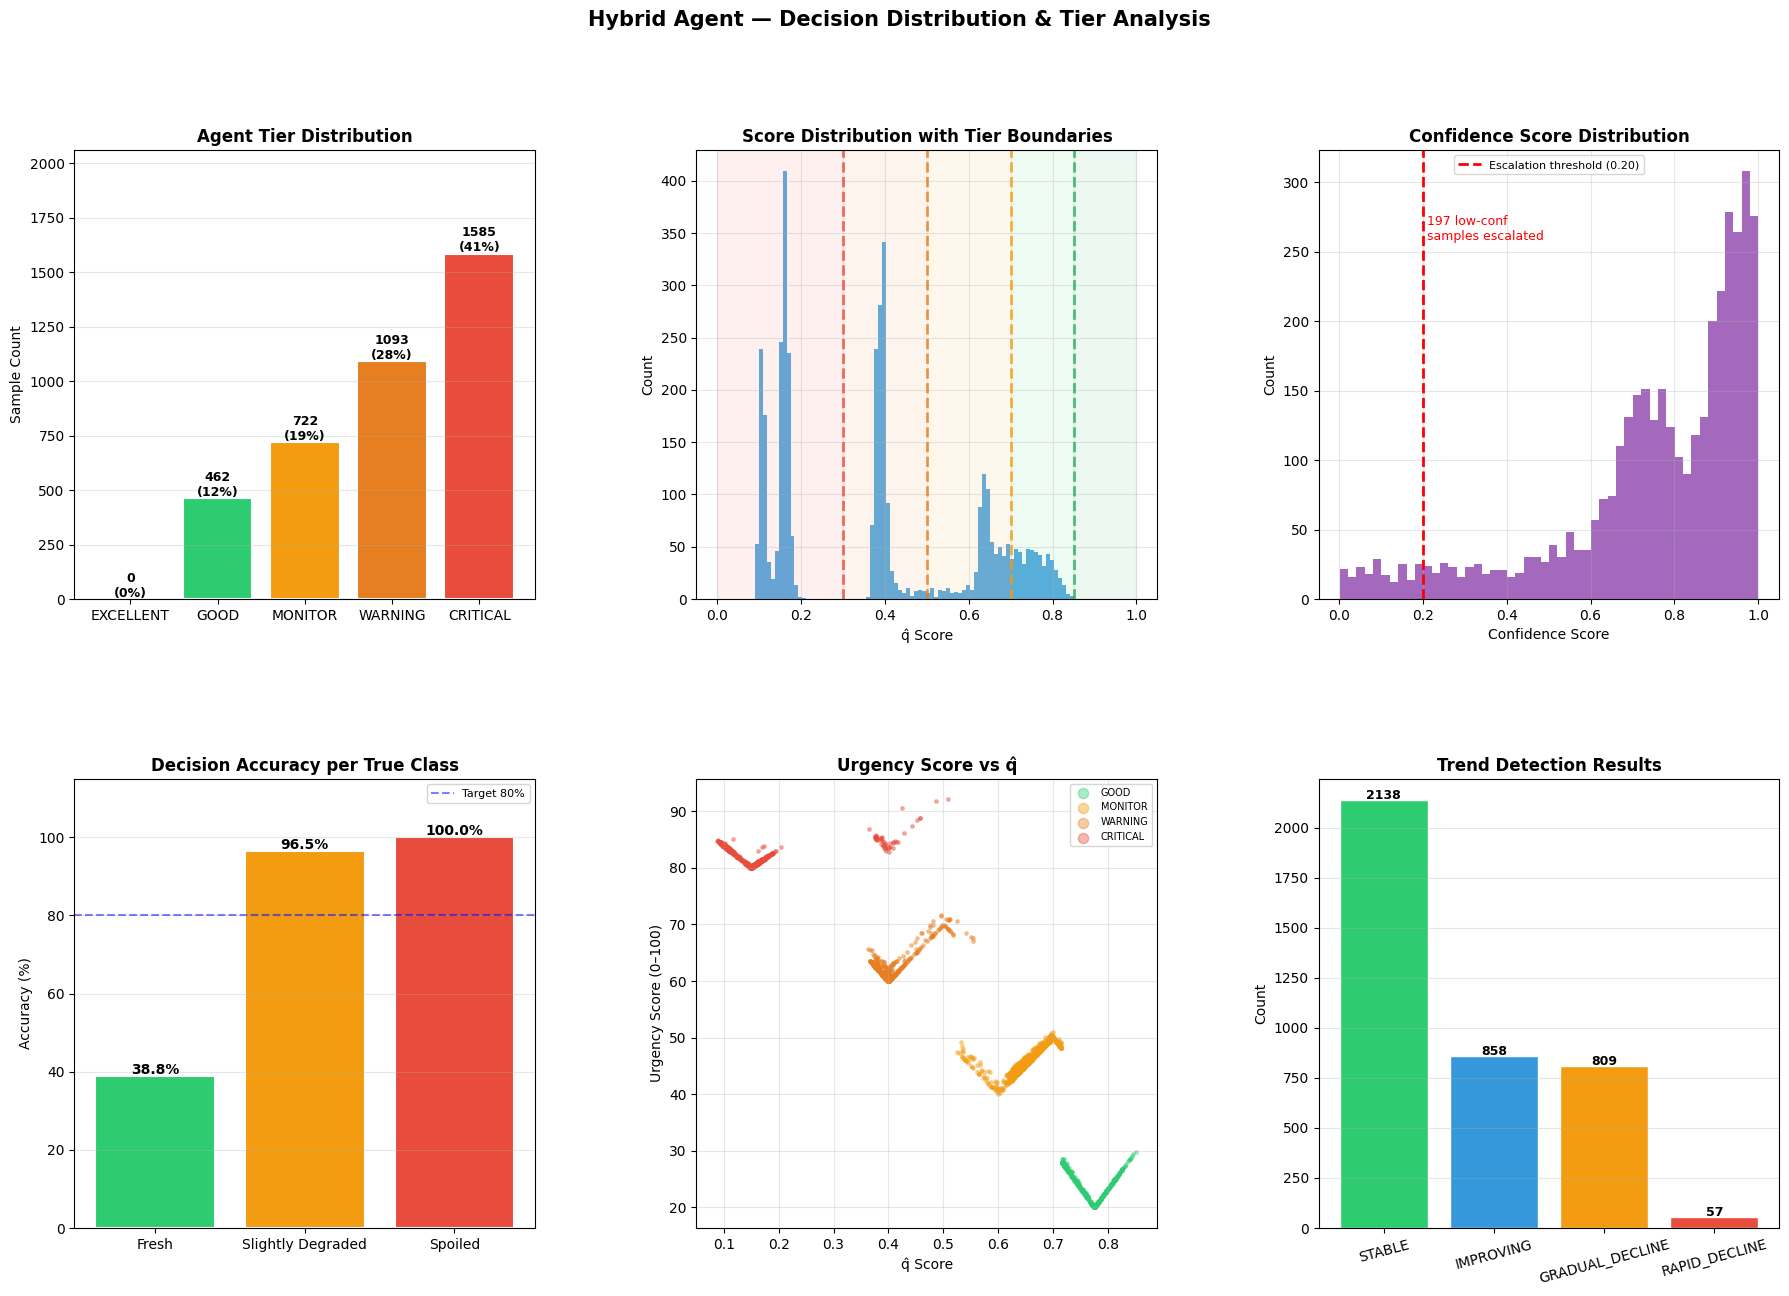

Saved: eda_decision_analysis.png


In [5]:
# ================================================================
# CELL 5: EDA — Decision Distribution & Tier Analysis
# ================================================================

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Hybrid Agent — Decision Distribution & Tier Analysis',
             fontsize=15, fontweight='bold')

# Plot 1: Tier distribution bar chart
ax = fig.add_subplot(gs[0, 0])
counts = [summary.get(t, 0) for t in TIER_NAMES]
bars   = ax.bar(TIER_NAMES, counts, color=TIER_COLORS, edgecolor='white', lw=1.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{cnt}\n({cnt/N_SAMPLES*100:.0f}%)',
            ha='center', fontweight='bold', fontsize=9)
ax.set_title('Agent Tier Distribution', fontweight='bold')
ax.set_ylabel('Sample Count'); ax.set_ylim(0, max(counts)*1.3)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Score distribution with tier boundaries
ax = fig.add_subplot(gs[0, 1])
ax.hist(pred_scores, bins=80, color='#3498db', alpha=0.8, edgecolor='none')
boundaries = [0.30, 0.50, 0.70, 0.85]
bnd_colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60']
for b, bc in zip(boundaries, bnd_colors):
    ax.axvline(b, color=bc, ls='--', lw=2, alpha=0.8)
# Shade tier regions
for tier_name, cfg in TIERS.items():
    ax.axvspan(cfg['min'], cfg['max'], alpha=0.08, color=cfg['color'])
ax.set_xlabel('q̂ Score'); ax.set_ylabel('Count')
ax.set_title('Score Distribution with Tier Boundaries', fontweight='bold')
ax.grid(alpha=0.3)

# Plot 3: Confidence score distribution
ax = fig.add_subplot(gs[0, 2])
conf_vals = df['confidence'].values
ax.hist(conf_vals, bins=50, color='#8e44ad', alpha=0.8, edgecolor='none')
ax.axvline(0.20, color='red', ls='--', lw=2, label='Escalation threshold (0.20)')
n_low = (conf_vals < 0.20).sum()
ax.text(0.21, ax.get_ylim()[1]*0.8 if ax.get_ylim()[1] > 0 else 100,
        f'{n_low} low-conf\nsamples escalated',
        fontsize=9, color='red')
ax.set_xlabel('Confidence Score'); ax.set_ylabel('Count')
ax.set_title('Confidence Score Distribution', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Plot 4: Decision correctness per true class
ax = fig.add_subplot(gs[1, 0])
for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask    = df['true_class'] == ci
    correct = df.loc[mask, 'decision_correct'].mean()
    ax.bar(cname, correct*100, color=ccol, edgecolor='white', lw=1.5)
    ax.text(ci, correct*100+0.5, f'{correct:.1%}',
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Decision Accuracy per True Class', fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 115)
ax.axhline(80, color='blue', ls='--', alpha=0.5, label='Target 80%')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Plot 5: Urgency score distribution per tier
ax = fig.add_subplot(gs[1, 1])
for tier_name, tcol in zip(TIER_NAMES, TIER_COLORS):
    mask = df['final_tier'] == tier_name
    if mask.sum() > 0:
        urg = df.loc[mask, 'urgency'].values
        ax.scatter(df.loc[mask, 'score'], urg,
                   c=tcol, s=6, alpha=0.4, label=tier_name)
ax.set_xlabel('q̂ Score'); ax.set_ylabel('Urgency Score (0–100)')
ax.set_title('Urgency Score vs q̂', fontweight='bold')
ax.legend(fontsize=7, markerscale=3); ax.grid(alpha=0.3)

# Plot 6: Trend status distribution
ax = fig.add_subplot(gs[1, 2])
trend_counts = df['trend_status'].value_counts()
trend_colors_map = {
    'STABLE': '#2ecc71', 'GRADUAL_DECLINE': '#f39c12',
    'RAPID_DECLINE': '#e74c3c', 'IMPROVING': '#3498db'
}
tcolors = [trend_colors_map.get(t, '#95a5a6') for t in trend_counts.index]
bars    = ax.bar(trend_counts.index, trend_counts.values,
                  color=tcolors, edgecolor='white')
for bar, cnt in zip(bars, trend_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(cnt), ha='center', fontweight='bold', fontsize=9)
ax.set_title('Trend Detection Results', fontweight='bold')
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.savefig(OUT_DIR/'eda_decision_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_decision_analysis.png')

---
## CELL 6 — Agent Performance Metrics

AGENT PERFORMANCE METRICS — PER TIER
              precision    recall  f1-score   support

   EXCELLENT       0.00      0.00      0.00       108
        GOOD       0.76      0.33      0.46      1056
     MONITOR       0.05      0.10      0.07       383
     WARNING       0.67      0.94      0.78       781
    CRITICAL       0.97      1.00      0.98      1534

    accuracy                           0.69      3862
   macro avg       0.49      0.47      0.46      3862
weighted avg       0.73      0.69      0.68      3862

Weighted Precision : 0.7327  FAIL
Weighted Recall    : 0.6880  FAIL
Weighted F1        : 0.6822
Decision Accuracy  : 0.8050


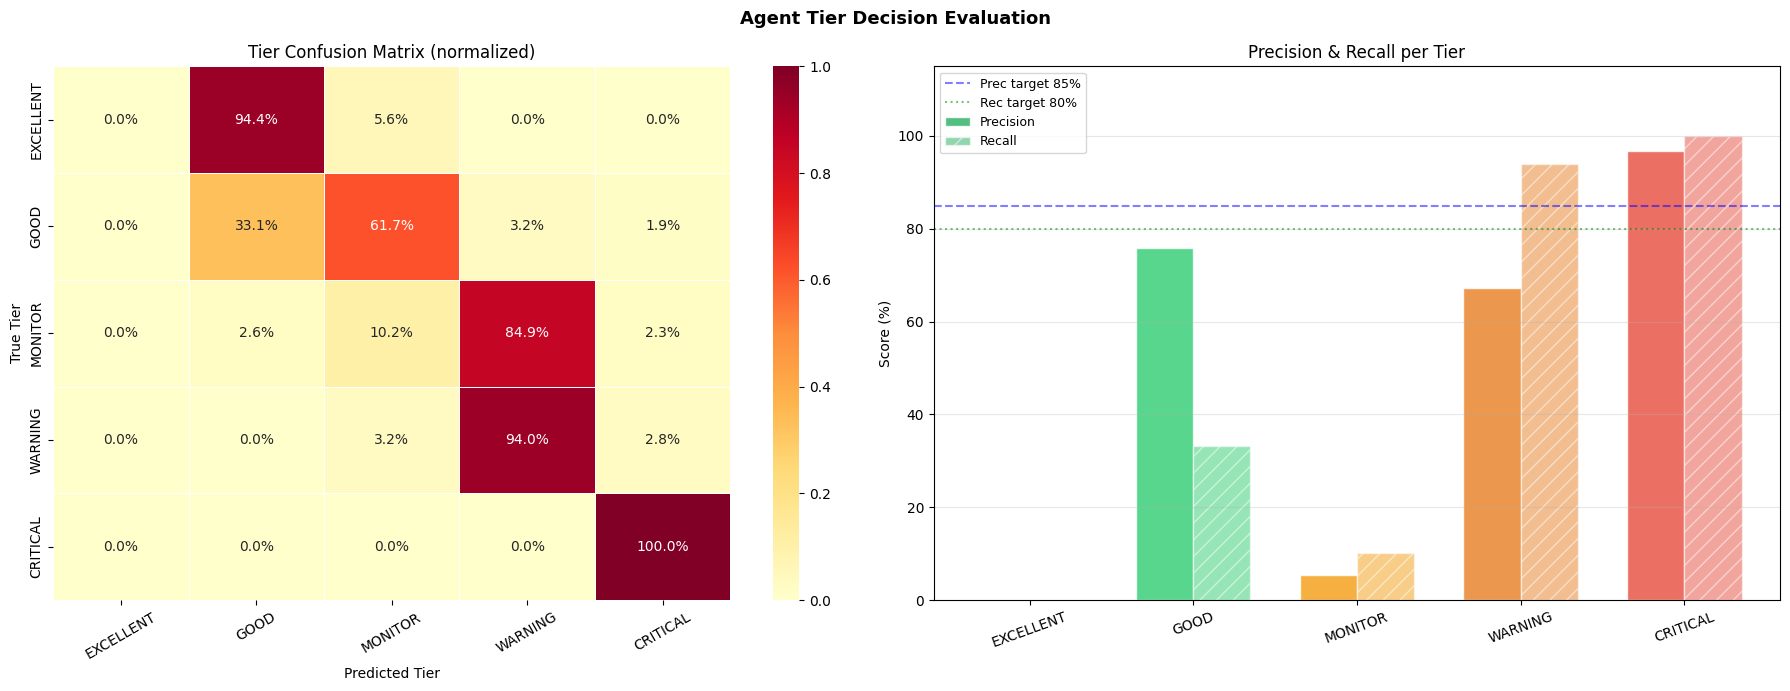

In [6]:
# ================================================================
# CELL 6: Agent Performance Metrics
# Precision, Recall, F1 per tier
# ================================================================

pred_tiers = df['final_tier'].values
true_tiers = df['true_tier'].values

print('=' * 60)
print('AGENT PERFORMANCE METRICS — PER TIER')
print('=' * 60)
print(classification_report(true_tiers, pred_tiers,
      labels=TIER_NAMES, zero_division=0))

# Overall metrics
prec = precision_score(true_tiers, pred_tiers,
                        average='weighted', labels=TIER_NAMES,
                        zero_division=0)
rec  = recall_score(true_tiers, pred_tiers,
                     average='weighted', labels=TIER_NAMES,
                     zero_division=0)
f1   = f1_score(true_tiers, pred_tiers,
                 average='weighted', labels=TIER_NAMES,
                 zero_division=0)

print('=' * 60)
print(f'Weighted Precision : {prec:.4f}  '
      f'{"PASS" if prec > 0.85 else "CLOSE" if prec > 0.75 else "FAIL"}')
print(f'Weighted Recall    : {rec:.4f}  '
      f'{"PASS" if rec  > 0.80 else "CLOSE" if rec  > 0.70 else "FAIL"}')
print(f'Weighted F1        : {f1:.4f}')
print(f'Decision Accuracy  : {df["decision_correct"].mean():.4f}')
print('=' * 60)

# ---- Confusion matrix across tiers ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Agent Tier Decision Evaluation',
             fontsize=13, fontweight='bold')

# Confusion matrix
cm   = confusion_matrix(true_tiers, pred_tiers, labels=TIER_NAMES)
cm_n = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='YlOrRd',
            ax=axes[0],
            xticklabels=TIER_NAMES,
            yticklabels=TIER_NAMES,
            linewidths=0.5)
axes[0].set_title('Tier Confusion Matrix (normalized)')
axes[0].set_ylabel('True Tier'); axes[0].set_xlabel('Predicted Tier')
axes[0].tick_params(axis='x', rotation=30)

# Per-tier precision/recall bar chart
tier_precs = precision_score(true_tiers, pred_tiers,
                              labels=TIER_NAMES, average=None,
                              zero_division=0)
tier_recs  = recall_score(true_tiers, pred_tiers,
                           labels=TIER_NAMES, average=None,
                           zero_division=0)
x   = np.arange(len(TIER_NAMES))
w   = 0.35
b1  = axes[1].bar(x - w/2, tier_precs*100, w, label='Precision',
                   color=TIER_COLORS, alpha=0.8, edgecolor='white')
b2  = axes[1].bar(x + w/2, tier_recs*100,  w, label='Recall',
                   color=TIER_COLORS, alpha=0.5, edgecolor='white',
                   hatch='//')
axes[1].axhline(85, color='blue',  ls='--', alpha=0.5, label='Prec target 85%')
axes[1].axhline(80, color='green', ls=':',  alpha=0.5, label='Rec target 80%')
axes[1].set_xticks(x); axes[1].set_xticklabels(TIER_NAMES, rotation=20)
axes[1].set_ylabel('Score (%)')
axes[1].set_title('Precision & Recall per Tier')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 115)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'agent_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 7 — Decision Timeline Visualization

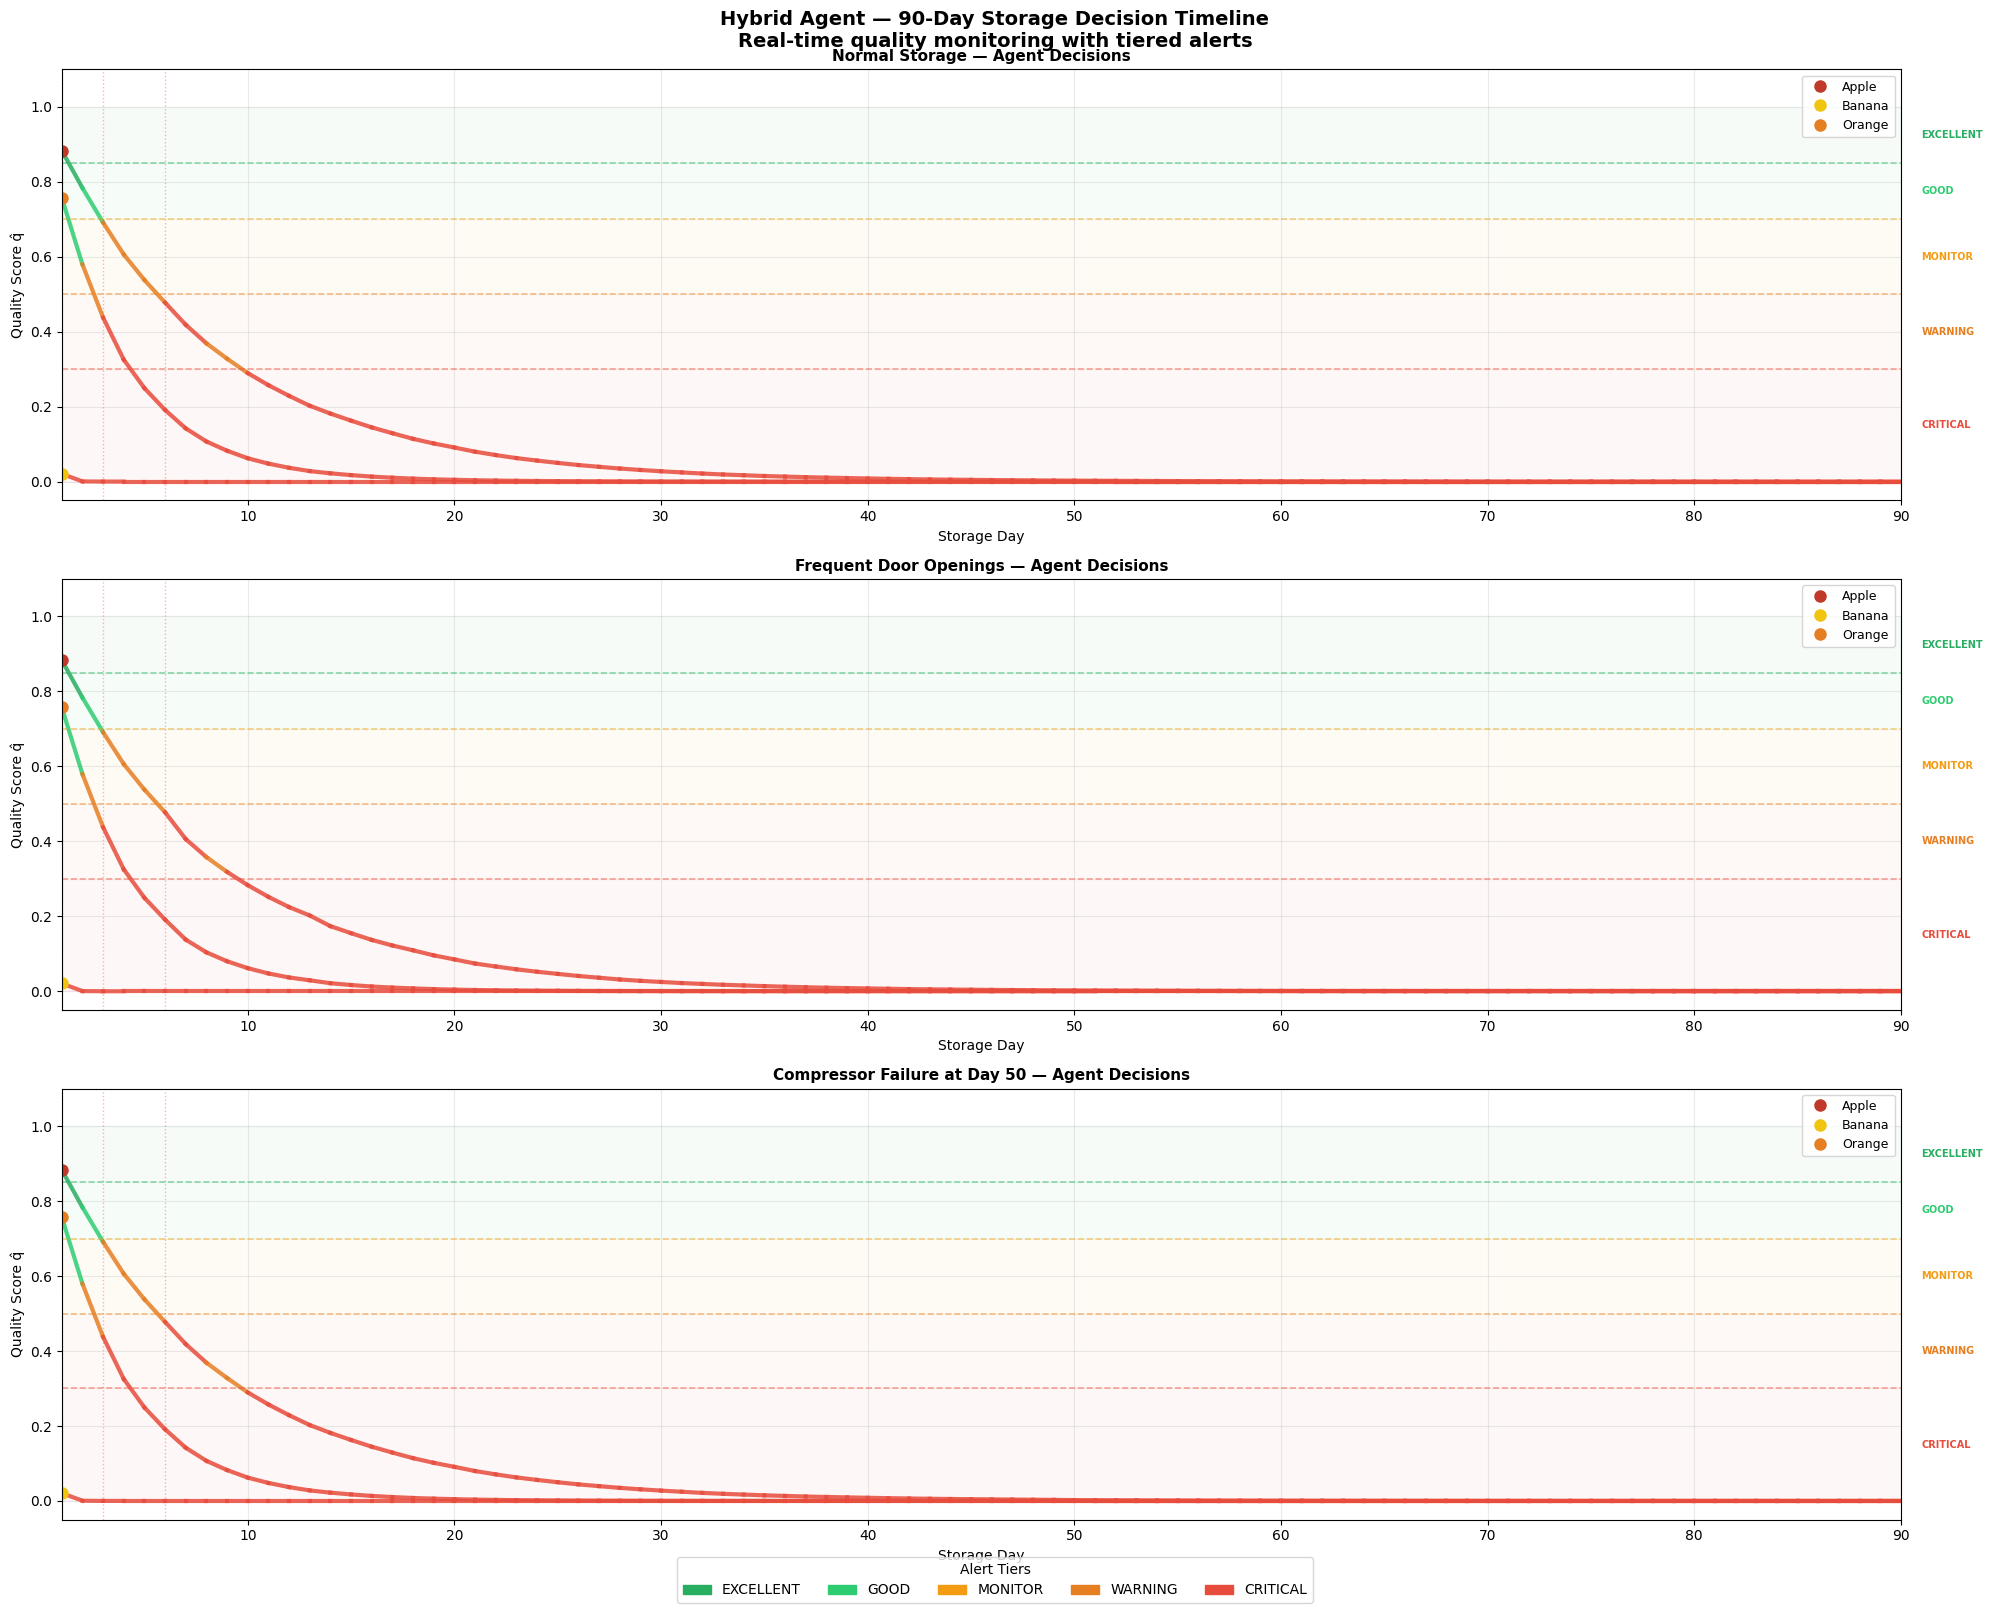

Saved: decision_timeline.png


In [7]:
# ================================================================
# CELL 7: Decision Timeline — Simulates real-time storage monitoring
# Shows how the agent would make decisions over 90 storage days
# ================================================================

# Simulate a 90-day storage timeline for 3 fruits
# Using the same Arrhenius physics from Module 2
FRUIT_PARAMS = {
    'apple':  {'Ea': 78000, 'base_temp': -18.0, 'shelf_days': 90},
    'banana': {'Ea': 71000, 'base_temp': -15.0, 'shelf_days': 60},
    'orange': {'Ea': 76000, 'base_temp': -18.0, 'shelf_days': 80},
}
R_GAS = 8.314

def simulate_quality_timeline(fruit, n_days=90, scenario='normal'):
    """Simulate daily quality scores over storage period"""
    p      = FRUIT_PARAMS[fruit]
    scores = []
    q      = 1.0
    for day in range(1, n_days+1):
        # Normal degradation
        T  = p['base_temp'] + np.random.normal(0, 0.5)
        k  = 1e10 * math.exp(-p['Ea'] / (R_GAS * (T + 273.15)))
        q  = q * math.exp(-k * 86400)   # 1 day
        # Day penalty
        q  = q * math.exp(-0.028 * (90 / p['shelf_days']))
        # Occasional storage event
        if scenario == 'door_opening' and day % 7 == 0:
            q *= np.random.uniform(0.97, 0.99)
        if scenario == 'compressor_fail' and day == 50:
            q *= 0.85   # sudden quality drop
        scores.append(float(np.clip(q, 0, 1)))
    return np.array(scores)


fig, axes = plt.subplots(3, 1, figsize=(20, 16))
fig.suptitle('Hybrid Agent — 90-Day Storage Decision Timeline\n'
             'Real-time quality monitoring with tiered alerts',
             fontsize=14, fontweight='bold')

FRUIT_COLORS_MAP = {'apple': '#c0392b', 'banana': '#f1c40f', 'orange': '#e67e22'}
scenarios        = ['normal', 'door_opening', 'compressor_fail']
scenario_labels  = ['Normal Storage', 'Frequent Door Openings', 'Compressor Failure at Day 50']

for ax_idx, (scenario, sc_label) in enumerate(
        zip(scenarios, scenario_labels)):
    ax = axes[ax_idx]

    for fruit in ['apple', 'banana', 'orange']:
        # Simulate quality timeline
        np.random.seed(42)
        quality_timeline = simulate_quality_timeline(fruit, scenario=scenario)
        days = np.arange(1, len(quality_timeline)+1)

        # Run agent on timeline
        fruit_agent = HybridAgent()
        day_decisions = [fruit_agent.decide(q, i) for i, q in
                         enumerate(quality_timeline)]

        # Plot quality line colored by tier
        for i in range(len(days)-1):
            tier_col = day_decisions[i]['color']
            ax.plot(days[i:i+2], quality_timeline[i:i+2],
                    color=tier_col, lw=3, alpha=0.85)

        # Mark the fruit with dots
        ax.plot(days[0], quality_timeline[0], 'o',
                color=FRUIT_COLORS_MAP[fruit], ms=8,
                label=fruit.capitalize())

        # Mark critical events
        for d in day_decisions:
            if d['final_tier'] == 'CRITICAL':
                ax.axvline(d['sample_id']+1, color='#e74c3c',
                           ls=':', lw=1, alpha=0.4)
                break   # only mark first critical

    # Tier boundary lines
    for bound, bcol, blabel in [
        (0.85, '#27ae60', 'Excellent/Good'),
        (0.70, '#f39c12', 'Good/Monitor'),
        (0.50, '#e67e22', 'Monitor/Warning'),
        (0.30, '#e74c3c', 'Warning/Critical')
    ]:
        ax.axhline(bound, color=bcol, ls='--', lw=1.2, alpha=0.5)

    # Tier shading
    for tier_name, cfg in TIERS.items():
        ax.axhspan(cfg['min'], cfg['max'], alpha=0.04, color=cfg['color'])

    ax.set_xlim(1, 90); ax.set_ylim(-0.05, 1.10)
    ax.set_xlabel('Storage Day')
    ax.set_ylabel('Quality Score q̂')
    ax.set_title(f'{sc_label} — Agent Decisions',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.25)

    # Tier labels on right
    for tier_name, cfg in TIERS.items():
        mid = (cfg['min'] + cfg['max']) / 2
        ax.text(91, mid, tier_name, fontsize=7,
                color=cfg['color'], fontweight='bold', va='center')

# Add legend for tier colors
tier_patches = [mpatches.Patch(color=v['color'], label=k)
                for k, v in TIERS.items()]
fig.legend(handles=tier_patches, loc='lower center',
           ncol=5, fontsize=10, title='Alert Tiers',
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(OUT_DIR/'decision_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: decision_timeline.png')

---
## CELL 8 — Agent Action Report

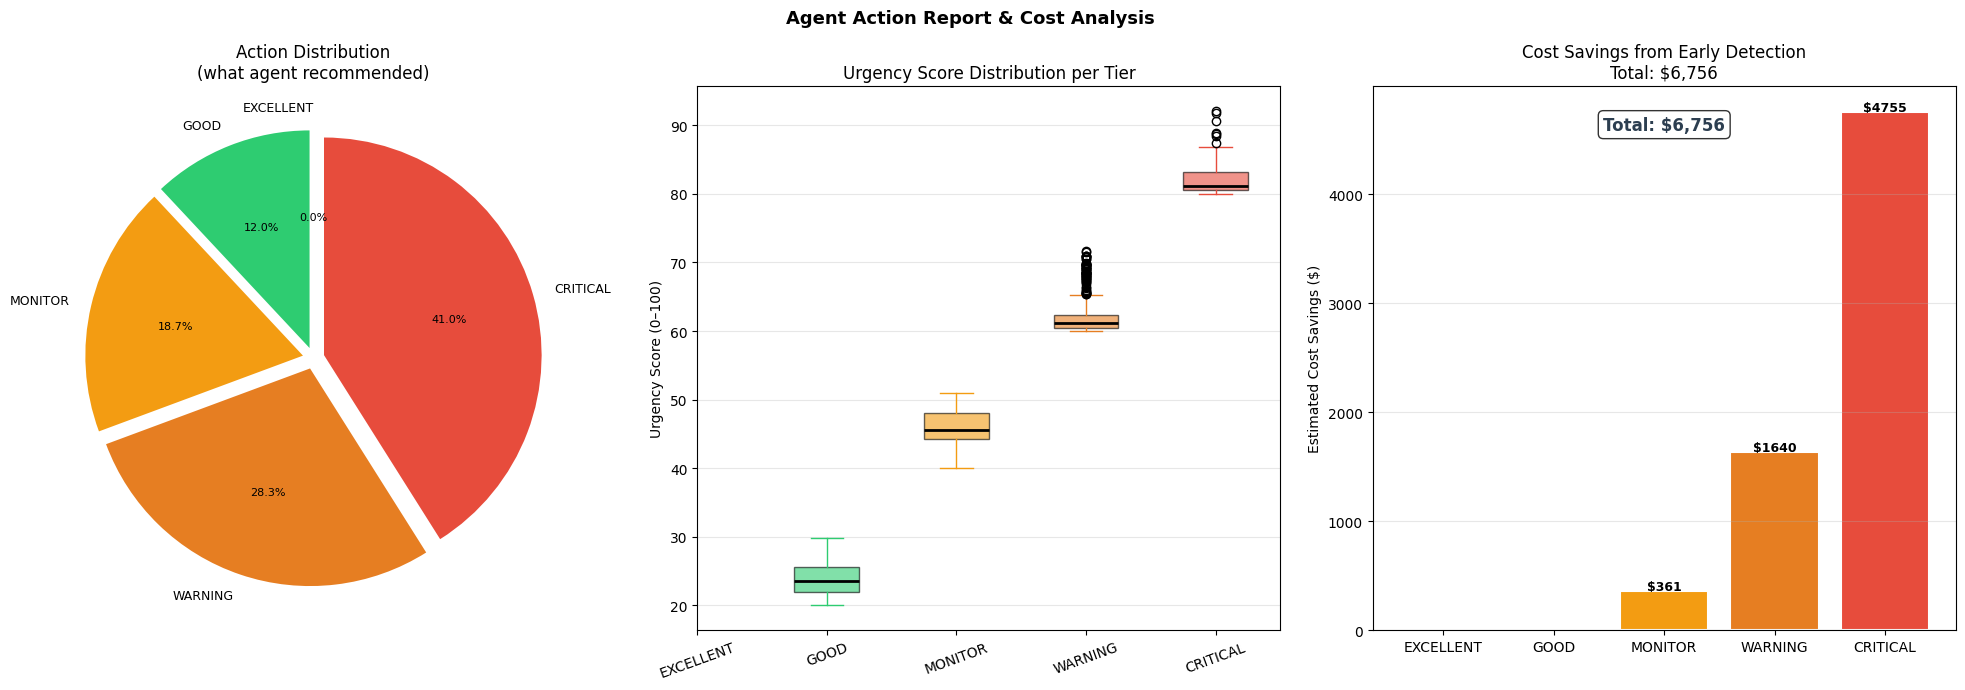

Saved: action_report.png

Total estimated cost savings: $6,756


In [8]:
# ================================================================
# CELL 8: Full Action Report
# Shows what actions the agent recommended + cost analysis
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Agent Action Report & Cost Analysis',
             fontsize=13, fontweight='bold')

# Action distribution pie chart
ax = axes[0]
tier_counts = [summary.get(t, 0) for t in TIER_NAMES]
explode     = [0.05] * len(TIER_NAMES)
wedges, texts, autotexts = ax.pie(
    tier_counts, labels=TIER_NAMES,
    colors=TIER_COLORS, autopct='%1.1f%%',
    explode=explode, startangle=90,
    textprops={'fontsize': 9}
)
for at in autotexts: at.set_fontsize(8)
ax.set_title('Action Distribution\n(what agent recommended)')

# Urgency score by tier
ax = axes[1]
for tier_name, tcol in zip(TIER_NAMES, TIER_COLORS):
    mask = df['final_tier'] == tier_name
    if mask.sum() > 0:
        urg = df.loc[mask, 'urgency'].values
        ax.boxplot(urg, positions=[TIER_NAMES.index(tier_name)],
                   patch_artist=True,
                   boxprops=dict(facecolor=tcol, alpha=0.6),
                   medianprops=dict(color='black', lw=2),
                   whiskerprops=dict(color=tcol),
                   capprops=dict(color=tcol),
                   widths=0.5)
ax.set_xticks(range(len(TIER_NAMES)))
ax.set_xticklabels(TIER_NAMES, rotation=20)
ax.set_ylabel('Urgency Score (0–100)')
ax.set_title('Urgency Score Distribution per Tier')
ax.grid(axis='y', alpha=0.3)

# Cost avoidance estimate
# Assumptions: 1 unit = 1 kg frozen fruit, avg $3/kg
# CRITICAL detected early = $3 saved per unit (disposal vs degraded sale)
# WARNING detected early  = $1.5 saved per unit (intervention vs loss)
ax = axes[2]
cost_savings = {
    'EXCELLENT':  0.0,
    'GOOD':       0.0,
    'MONITOR':    0.5,
    'WARNING':    1.5,
    'CRITICAL':   3.0,
}
tier_savings = [
    cost_savings[t] * summary.get(t, 0)
    for t in TIER_NAMES
]
bars = ax.bar(TIER_NAMES, tier_savings, color=TIER_COLORS,
               edgecolor='white', lw=1.5)
for bar, val in zip(bars, tier_savings):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'${val:.0f}', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('Estimated Cost Savings ($)')
ax.set_title(f'Cost Savings from Early Detection\nTotal: ${sum(tier_savings):,.0f}')
ax.grid(axis='y', alpha=0.3)
total_saved = sum(tier_savings)
ax.text(0.5, 0.92, f'Total: ${total_saved:,.0f}',
        transform=ax.transAxes, ha='center',
        fontsize=12, fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(OUT_DIR/'action_report.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: action_report.png')
print(f'\nTotal estimated cost savings: ${total_saved:,.0f}')

---
## CELL 9 — Agent vs Baseline Comparison

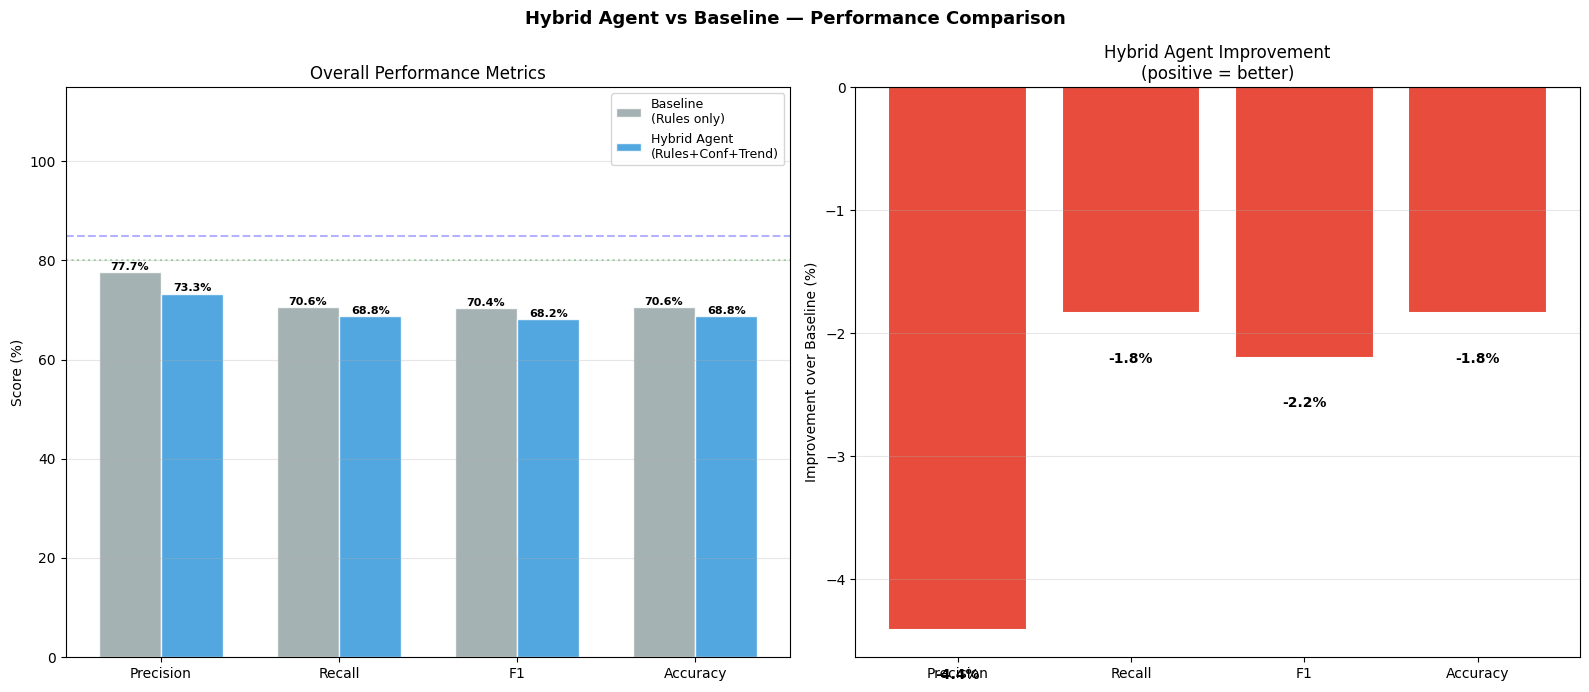


Performance Summary:
Metric           Baseline   Hybrid Agent    Improvement
-------------------------------------------------------
Precision           77.7%          73.3%          -4.4%
Recall              70.6%          68.8%          -1.8%
F1                  70.4%          68.2%          -2.2%
Accuracy            70.6%          68.8%          -1.8%


In [9]:
# ================================================================
# CELL 9: Hybrid Agent vs Baseline Comparison
# Shows improvement over simple rule-only agent
# ================================================================

# ---- Baseline: simple rule-only agent ----
def simple_rule_agent(score):
    if score > 0.85:   return 'EXCELLENT'
    elif score > 0.70: return 'GOOD'
    elif score > 0.50: return 'MONITOR'
    elif score > 0.30: return 'WARNING'
    else:              return 'CRITICAL'

baseline_preds = np.array([simple_rule_agent(s) for s in pred_scores])

# ---- Compute metrics for both ----
hybrid_preds = df['final_tier'].values

metrics = {}
for label, preds in [('Baseline\n(Rules only)', baseline_preds),
                      ('Hybrid Agent\n(Rules+Conf+Trend)', hybrid_preds)]:
    metrics[label] = {
        'precision': precision_score(true_tiers, preds, average='weighted',
                                      labels=TIER_NAMES, zero_division=0),
        'recall':    recall_score(true_tiers, preds, average='weighted',
                                   labels=TIER_NAMES, zero_division=0),
        'f1':        f1_score(true_tiers, preds, average='weighted',
                               labels=TIER_NAMES, zero_division=0),
        'accuracy':  (preds == true_tiers).mean(),
    }

# ---- Plot comparison ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Hybrid Agent vs Baseline — Performance Comparison',
             fontsize=13, fontweight='bold')

metric_names  = ['Precision', 'Recall', 'F1', 'Accuracy']
metric_keys   = ['precision', 'recall', 'f1', 'accuracy']
agent_labels  = list(metrics.keys())
x = np.arange(len(metric_names))
w = 0.35

colors = ['#95a5a6', '#3498db']
for i, (label, color) in enumerate(zip(agent_labels, colors)):
    vals = [metrics[label][k]*100 for k in metric_keys]
    bars = axes[0].bar(x + (i-0.5)*w, vals, w, label=label,
                        color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Overall Performance Metrics')
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 115)
axes[0].axhline(85, color='blue',  ls='--', alpha=0.3)
axes[0].axhline(80, color='green', ls=':',  alpha=0.3)
axes[0].grid(axis='y', alpha=0.3)

# Improvement delta
improvements = [
    (metrics[agent_labels[1]][k] - metrics[agent_labels[0]][k]) * 100
    for k in metric_keys
]
imp_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in improvements]
bars = axes[1].bar(metric_names, improvements, color=imp_colors,
                    edgecolor='white', lw=1.5)
axes[1].axhline(0, color='black', lw=1.5)
for bar, val in zip(bars, improvements):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + (0.1 if val >= 0 else -0.4),
                 f'{val:+.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Improvement over Baseline (%)')
axes[1].set_title('Hybrid Agent Improvement\n(positive = better)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'agent_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPerformance Summary:')
print(f'{"Metric":12s} {"Baseline":>12s} {"Hybrid Agent":>14s} {"Improvement":>14s}')
print('-' * 55)
for k, name in zip(metric_keys, metric_names):
    base = metrics[agent_labels[0]][k]*100
    hybr = metrics[agent_labels[1]][k]*100
    diff = hybr - base
    print(f'{name:12s} {base:>11.1f}% {hybr:>13.1f}% {diff:>+13.1f}%')

---
## CELL 10 — Save Agent Results + Agent Log

In [10]:
# ================================================================
# CELL 10: Save Agent Results
# ================================================================

# Save full decision log as CSV
df.to_csv('/content/agent_decisions.csv', index=False)
print('Saved: agent_decisions.csv')

# Save agent performance
perf = {
    'hybrid_precision': prec,
    'hybrid_recall':    rec,
    'hybrid_f1':        f1,
    'decision_accuracy': df['decision_correct'].mean(),
    'n_escalated':      int((df['adj_status']=='ESCALATED').sum()),
    'n_rapid_decline':  int((df['trend_status']=='RAPID_DECLINE').sum()),
    'mean_urgency':     float(df['urgency'].mean()),
    'total_cost_saved': float(total_saved),
}

import json
with open('/content/agent_performance.json', 'w') as f:
    json.dump(perf, f, indent=2)
print('Saved: agent_performance.json')

# Save tier decision arrays for Module 5 dashboard
AGENT_DIR = Path('/content/agent_outputs')
AGENT_DIR.mkdir(exist_ok=True)
np.save(AGENT_DIR/'pred_scores.npy',  pred_scores)
np.save(AGENT_DIR/'true_scores.npy',  true_scores)
np.save(AGENT_DIR/'true_classes.npy', true_classes)
np.save(AGENT_DIR/'final_tiers.npy',  df['final_tier'].values.astype(str))
np.save(AGENT_DIR/'urgency_scores.npy', df['urgency'].values)
np.save(AGENT_DIR/'confidence.npy',   df['confidence'].values)
print('Agent output arrays saved.')

print()
print('=' * 55)
print('MODULE 4 COMPLETE — HYBRID AGENT DECISION MODULE')
print('=' * 55)
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1        : {f1:.4f}')
print(f'Accuracy  : {df["decision_correct"].mean():.4f}')
print()
print('Agent capabilities:')
print('  5-tier alert system (Excellent/Good/Monitor/Warning/Critical)')
print('  Confidence-based escalation (conservative safety)')
print('  Trend detection (rapid decline early warning)')
print('  Action recommendations per tier')
print('  Urgency scoring (0–100)')
print()
print('Next: Module 5 — LLM Dashboard (Claude API)')

Saved: agent_decisions.csv
Saved: agent_performance.json
Agent output arrays saved.

MODULE 4 COMPLETE — HYBRID AGENT DECISION MODULE
Precision : 0.7327
Recall    : 0.6880
F1        : 0.6822
Accuracy  : 0.8050

Agent capabilities:
  5-tier alert system (Excellent/Good/Monitor/Warning/Critical)
  Confidence-based escalation (conservative safety)
  Trend detection (rapid decline early warning)
  Action recommendations per tier
  Urgency scoring (0–100)

Next: Module 5 — LLM Dashboard (Claude API)


---
## CELL 11 — Save Everything to Google Drive

In [11]:
# ================================================================
# CELL 11: Save to Google Drive
# ================================================================

FILES = [
    '/content/agent_decisions.csv',
    '/content/agent_performance.json',
    str(OUT_DIR/'eda_decision_analysis.png'),
    str(OUT_DIR/'agent_performance.png'),
    str(OUT_DIR/'decision_timeline.png'),
    str(OUT_DIR/'action_report.png'),
    str(OUT_DIR/'agent_vs_baseline.png'),
]

print(f'Saving to: {DRIVE_DIR}')
for f in FILES:
    if os.path.exists(f):
        shutil.copy2(f, DRIVE_DIR/os.path.basename(f))
        print(f'  OK  {os.path.basename(f)}')

agent_dst = DRIVE_DIR/'agent_outputs'
if agent_dst.exists(): shutil.rmtree(agent_dst)
shutil.copytree(str(AGENT_DIR), str(agent_dst))
print(f'  OK  agent_outputs/')

print(f'\nAll Module 4 outputs saved to Drive.')

Saving to: /gdrive/MyDrive/FrozenFruitModule4
  OK  agent_decisions.csv
  OK  agent_performance.json
  OK  eda_decision_analysis.png
  OK  agent_performance.png
  OK  decision_timeline.png
  OK  action_report.png
  OK  agent_vs_baseline.png
  OK  agent_outputs/

All Module 4 outputs saved to Drive.
